In [1]:
# Cell 1: Import necessary functions
import sys
import os
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

if project_root not in sys.path:
    sys.path.append(project_root)


# Import the functions from common.py
from common.common import display_df, init_notebook

init_notebook()
# Cell 3: Create a sample DataFrame
sample_data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'Score': [85.5, 90.3, 78.9]
}
df = pd.DataFrame(sample_data)

# Cell 4: Display the DataFrame using display_df
display_df(df, output_format='table', headers_style={'color': 'white', 'background-color': '#007acc'})

,Name,Age,Score
0,Alice,25,85.50
1,Bob,30,90.30
2,Charlie,35,78.90



CSI Analysis Summary:
           Feature      CSI             Status  Is_Categorical
    numeric_stable 1.14e-02             STABLE           False
     numeric_drift 3.64e-01 SIGNIFICANT_CHANGE           False
categorical_stable 8.19e-04             STABLE            True
 categorical_drift 1.19e+00 SIGNIFICANT_CHANGE            True


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/csi_analysis/csi_values.png'

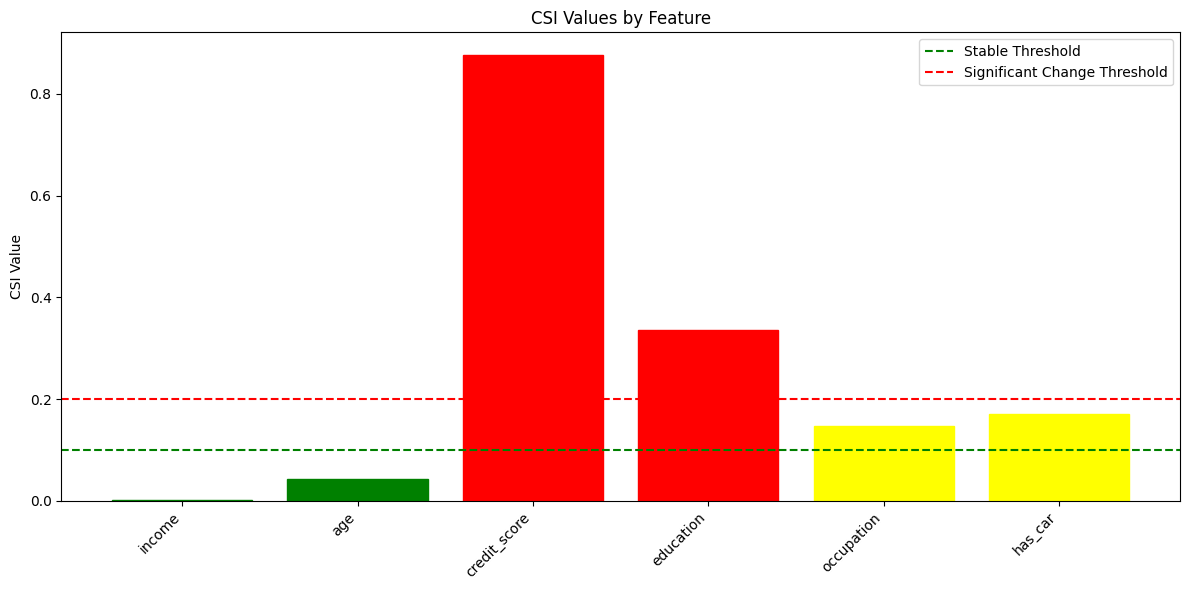

In [2]:
import pandas as pd
import numpy as np
from common.performance import calculate_csi_v2, analyze_csi_results

def demonstrate_csi_examples():
    """
    Demonstrate CSI calculation with different types of drift scenarios
    """
    # Set random seed for reproducibility
    np.random.seed(42)
    n_samples = 10000
    
    # Create baseline dataset
    baseline = pd.DataFrame({
        # Numeric features with different distributions
        'income': np.random.lognormal(10.5, 0.5, n_samples),  # Stable
        'age': np.random.normal(40, 10, n_samples),           # Minor drift
        'credit_score': np.random.normal(700, 50, n_samples), # Major drift
        
        # Categorical features
        'education': np.random.choice(
            ['High School', 'Bachelor', 'Master', 'PhD'],
            n_samples,
            p=[0.3, 0.4, 0.2, 0.1]
        ),
        'occupation': np.random.choice(
            ['Employed', 'Self-Employed', 'Retired', 'Student'],
            n_samples,
            p=[0.6, 0.2, 0.15, 0.05]
        ),
        
        # Binary feature
        'has_car': np.random.choice([0, 1], n_samples, p=[0.3, 0.7])
    })
    
    # Create validation dataset with various types of drift
    validation = pd.DataFrame({
        # Numeric features
        'income': np.random.lognormal(10.5, 0.5, n_samples),     # No drift
        'age': np.random.normal(42, 11, n_samples),              # Small drift
        'credit_score': np.random.normal(650, 70, n_samples),    # Large drift
        
        # Categorical features with changed distributions
        'education': np.random.choice(
            ['High School', 'Bachelor', 'Master', 'PhD', 'Other'],  # New category
            n_samples,
            p=[0.25, 0.35, 0.25, 0.1, 0.05]
        ),
        'occupation': np.random.choice(
            ['Employed', 'Self-Employed', 'Retired', 'Student'],
            n_samples,
            p=[0.4, 0.3, 0.2, 0.1]  # Changed proportions
        ),
        
        # Binary feature with drift
        'has_car': np.random.choice([0, 1], n_samples, p=[0.5, 0.5])
    })
    
    # Define features and their types
    features = ['income', 'age', 'credit_score', 'education', 'occupation', 'has_car']
    categorical_features = ['education', 'occupation', 'has_car']
    
    # Calculate CSI
    csi_results = calculate_csi_v2(
        baseline_sample=baseline,
        validation_sample=validation,
        features=features,
        categorical_features=categorical_features,
        bins=10  # Number of bins for numeric features
    )
    
    # Analyze and visualize results
    summary = analyze_csi_results(
        csi_results=csi_results,
        output_path='outputs/csi_analysis',  # Specify output path for plots
        plot=True
    )
    
    # Print detailed analysis
    print("\nDetailed CSI Analysis")
    print("====================")
    
    for feature in features:
        result = csi_results[feature]
        print(f"\nFeature: {feature}")
        print(f"Type: {'Categorical' if feature in categorical_features else 'Numeric'}")
        print(f"CSI Value: {result['csi']:.4f}")
        print(f"Status: {result['status']}")
        
        # Print top contributing bins/categories
        details = result['details']
        top_contributors = details.nlargest(3, 'Contribution_Pct')
        print("\nTop 3 Contributing Bins/Categories:")
        for idx, row in top_contributors.iterrows():
            print(f"- Bin/Category: {idx}")
            print(f"  Baseline %: {row['Baseline_Dist']*100:.2f}%")
            print(f"  Validation %: {row['Validation_Dist']*100:.2f}%")
            print(f"  Contribution: {row['Contribution_Pct']:.2f}%")
    
    # Print summary statistics
    print("\nSummary Statistics")
    print("=================")
    print(f"Total Features Analyzed: {len(features)}")
    print(f"Stable Features: {sum(summary['Status'] == 'STABLE')}")
    print(f"Features with Moderate Change: {sum(summary['Status'] == 'MODERATE_CHANGE')}")
    print(f"Features with Significant Change: {sum(summary['Status'] == 'SIGNIFICANT_CHANGE')}")
    
    return csi_results, summary

# Run the demonstration
if __name__ == "__main__":
    csi_results, summary = demonstrate_csi_examples()

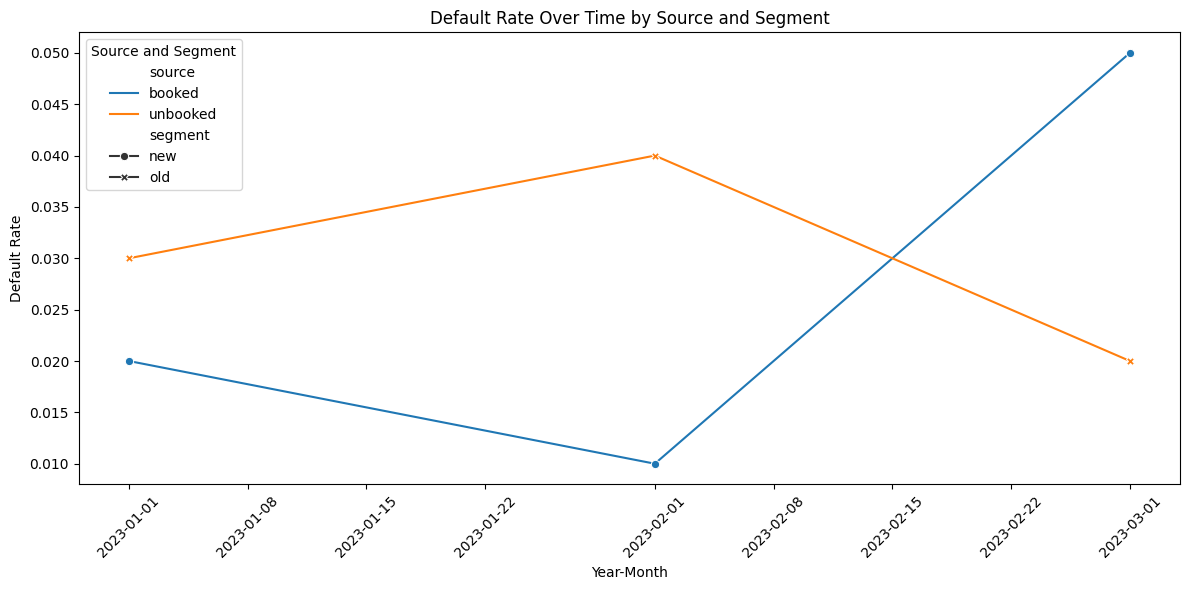

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Sample DataFrame
data = {
    'yrmth': ['2023-01', '2023-01', '2023-02', '2023-02', '2023-03', '2023-03'],
    'source': ['booked', 'unbooked', 'booked', 'unbooked', 'booked', 'unbooked'],
    'segment': ['new', 'old', 'new', 'old', 'new', 'old'],
    'default_rate': [0.02, 0.03, 0.01, 0.04, 0.05, 0.02]
}
df = pd.DataFrame(data)

# Convert 'yrmth' to datetime for better plotting
df['yrmth'] = pd.to_datetime(df['yrmth'])

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='yrmth', y='default_rate', hue='source', style='segment', markers=True, dashes=False)

# Customize the plot
plt.title('Default Rate Over Time by Source and Segment')
plt.xlabel('Year-Month')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.legend(title='Source and Segment')
plt.tight_layout()

# Show the plot
plt.show()

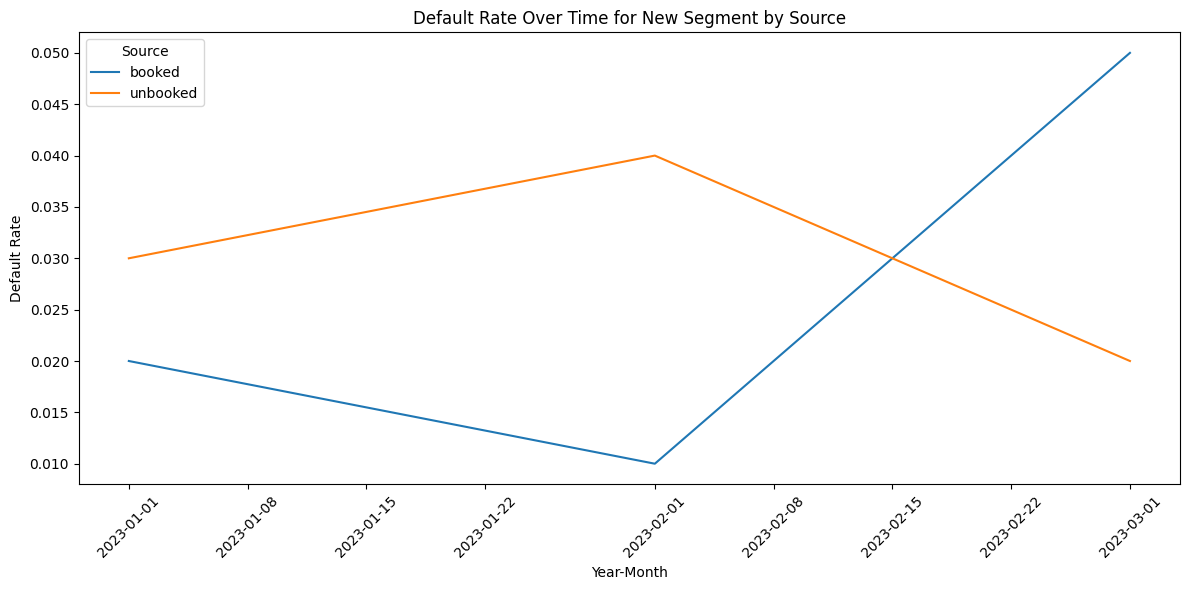

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample DataFrame
data = {
    'yrmth': ['2023-01', '2023-01', '2023-02', '2023-02', '2023-03', '2023-03'],
    'source': ['booked', 'unbooked', 'booked', 'unbooked', 'booked', 'unbooked'],
    'segment': ['new', 'new', 'new', 'new', 'new', 'new'],
    'default_rate': [0.02, 0.03, 0.01, 0.04, 0.05, 0.02]
}
df = pd.DataFrame(data)

# Convert 'yrmth' to datetime for better plotting
df['yrmth'] = pd.to_datetime(df['yrmth'])

# Filter for 'new' segment
df_new_segment = df[df['segment'] == 'new']

# Plotting for 'new' segment with separate lines for 'booked' and 'unbooked'
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_new_segment, x='yrmth', y='default_rate', hue='source', markers=True, dashes=False)

# Customize the plot
plt.title('Default Rate Over Time for New Segment by Source')
plt.xlabel('Year-Month')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.legend(title='Source')
plt.tight_layout()

# Show the plot
plt.show()

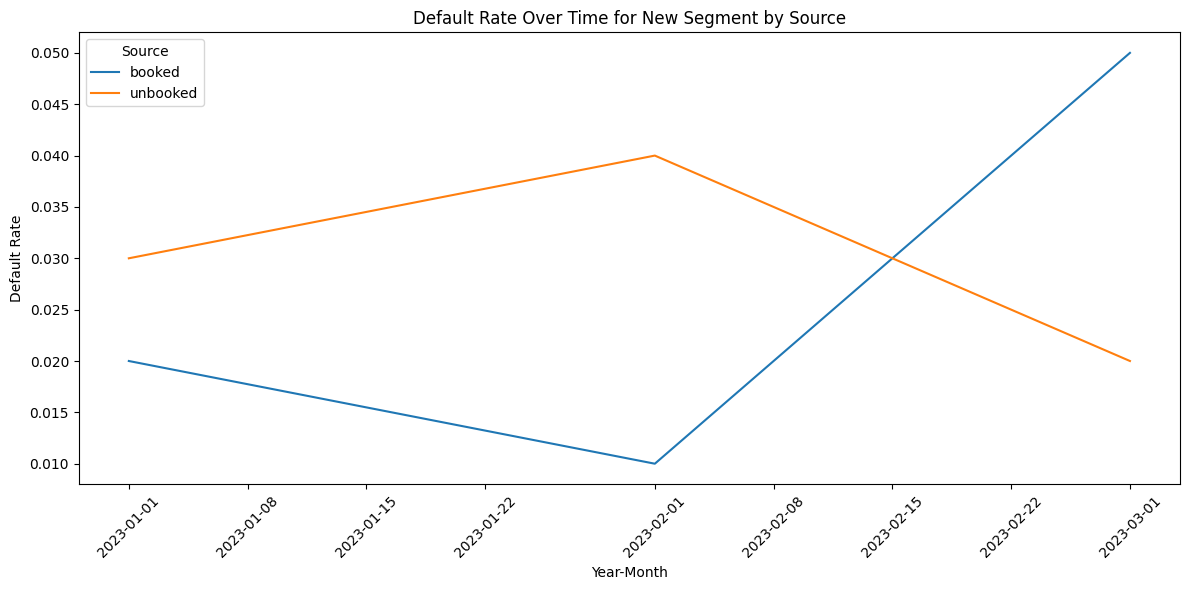

In [5]:
 import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample DataFrame with additional columns
data = {
    'yrmth': ['2023-01', '2023-01', '2023-02', '2023-02', '2023-03', '2023-03'],
    'source': ['booked', 'unbooked', 'booked', 'unbooked', 'booked', 'unbooked'],
    'segment': ['new', 'new', 'new', 'new', 'new', 'new'],
    'default_rate': [0.02, 0.03, 0.01, 0.04, 0.05, 0.02],
    'other_column1': [1, 2, 3, 4, 5, 6],  # Example of additional columns
    'other_column2': ['A', 'B', 'C', 'D', 'E', 'F']
}
df = pd.DataFrame(data)

# Convert 'yrmth' to datetime for better plotting
df['yrmth'] = pd.to_datetime(df['yrmth'])

# Filter for 'new' segment
df_new_segment = df[df['segment'] == 'new']

# Plotting for 'new' segment with separate lines for 'booked' and 'unbooked'
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_new_segment, x='yrmth', y='default_rate', hue='source', markers=True, dashes=False)

# Customize the plot
plt.title('Default Rate Over Time for New Segment by Source')
plt.xlabel('Year-Month')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.legend(title='Source')
plt.tight_layout()

# Show the plot
plt.show()